Saving archive (1).zip to archive (1).zip
First 5 rows of the dataset:


,ticker,asset_name,asset_type,stock_price,transaction,transaction_date,asset_value_low,asset_value_high,last_name,first_name,owner,additional_details
0,RTX,RTX Corporation Common Stock,Stock,100.99,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
1,DHR,Danaher Corp,Stock,249.80,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
2,UL,Unilever Plc ADR,Stock,47.99,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
3,IR,Ingersoll Rand Inc,Stock,93.48,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
4,NVS,Novartis Ag ADR,Stock,95.81,Sale (Partial),04/09/2024,1001,15000,Whitehouse,Sheldon,Self,--


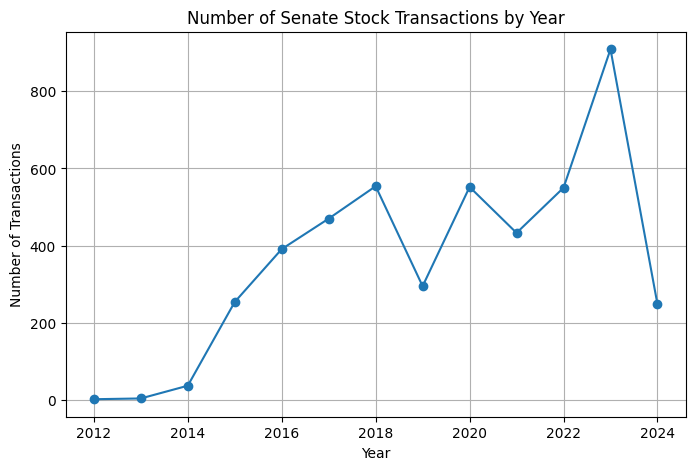

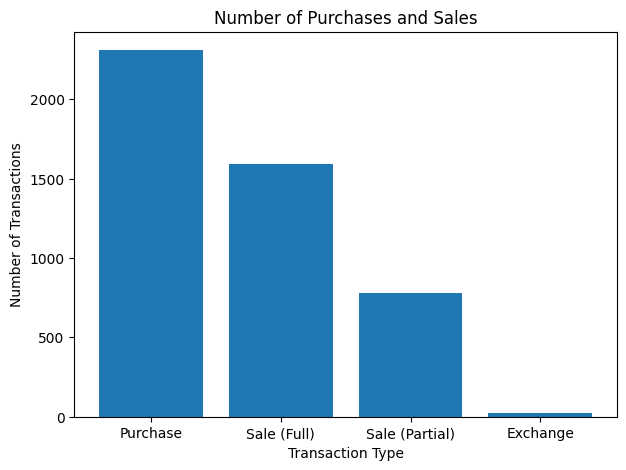

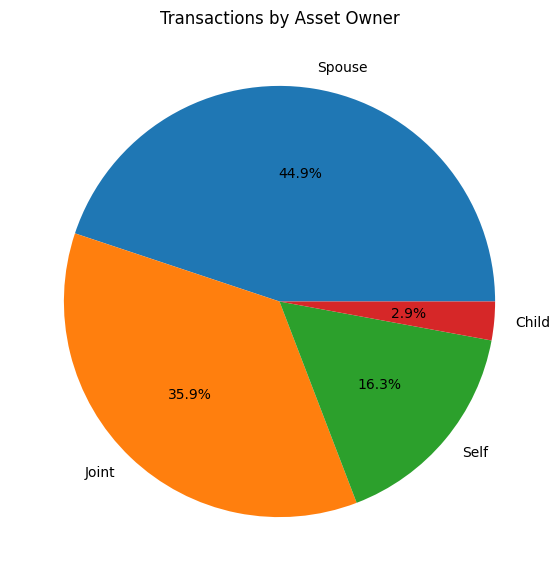

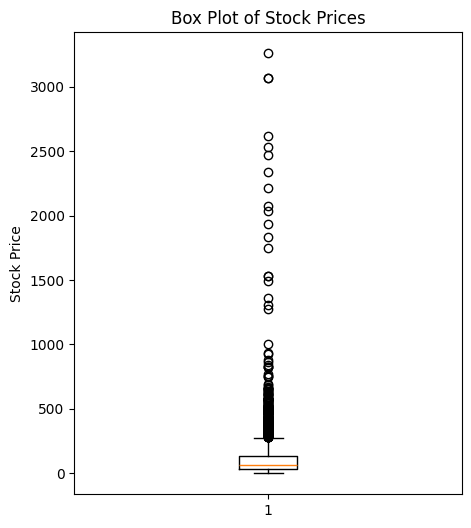

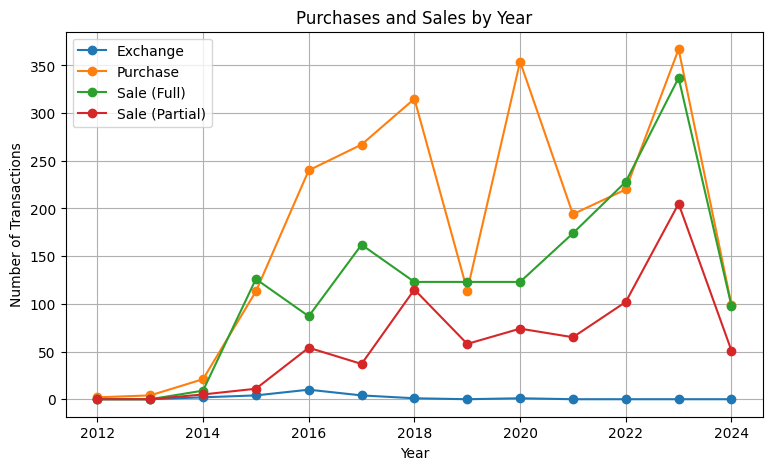

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Upload the CSV file in Google Colab
from google.colab import files
uploaded = files.upload()

# Replace this with the actual uploaded CSV filename if necessary
filename = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(filename)

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Convert columns to appropriate data types
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["stock_price"] = pd.to_numeric(df["stock_price"], errors="coerce")
df["asset_value_low"] = pd.to_numeric(df["asset_value_low"], errors="coerce")
df["asset_value_high"] = pd.to_numeric(df["asset_value_high"], errors="coerce")


# ---------------------------------------------------------
# 1. LINE CHART
# Number of transactions by year
# ---------------------------------------------------------

yearly_transactions = df["transaction_date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(
    yearly_transactions.index,
    yearly_transactions.values,
    marker="o"
)

plt.title("Number of Senate Stock Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 2. BAR CHART
# Number of purchases vs sales
# ---------------------------------------------------------

transaction_counts = df["transaction"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(
    transaction_counts.index,
    transaction_counts.values
)

plt.title("Number of Purchases and Sales")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()


# ---------------------------------------------------------
# 3. PIE CHART
# Transactions by owner
# ---------------------------------------------------------

owner_counts = df["owner"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    owner_counts.values,
    labels=owner_counts.index,
    autopct="%1.1f%%"
)

plt.title("Transactions by Asset Owner")
plt.show()


# ---------------------------------------------------------
# 4. BOX PLOT
# Distribution of stock prices
# ---------------------------------------------------------

stock_prices = df["stock_price"].dropna()

plt.figure(figsize=(5, 6))
plt.boxplot(stock_prices)

plt.title("Box Plot of Stock Prices")
plt.ylabel("Stock Price")
plt.show()


# ---------------------------------------------------------
# 5. MULTIPLE LINE CHART
# Purchases and sales by year
# ---------------------------------------------------------

year_transaction = pd.crosstab(
    df["transaction_date"].dt.year,
    df["transaction"]
)

plt.figure(figsize=(9, 5))

for column in year_transaction.columns:
    plt.plot(
        year_transaction.index,
        year_transaction[column],
        marker="o",
        label=column
    )

plt.title("Purchases and Sales by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.legend()
plt.grid(True)
plt.show()